# data preprocessing


In [1]:
# importing al the necessary libraries in this cell
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
from datetime import datetime
from sklearn.preprocessing import StandardScaler,PowerTransformer
from sklearn.impute  import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import silhouette_score,silhouette_samples


warnings.filterwarnings('ignore')

In [2]:
# laoding the data
df=pd.read_csv('data/marketing_campaign.csv',sep='\t')
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [3]:
na_col = [col for col in df.columns if df[col].isnull().sum()>0]
for features in na_col:
    print(features,np.round(df[features].isnull().mean()*100,2),'% are missing values')

Income 1.07 % are missing values


In [4]:
df[na_col].describe()

,Income
count,2216.000000
mean,52247.251354
std,25173.076661
min,1730.000000
25%,35303.000000
50%,51381.500000
75%,68522.000000
max,666666.000000


In [5]:
df['Income'].fillna(df['Income'].median(),inplace=True)

In [6]:
df['Income'].isnull().sum()

np.int64(0)

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='object')

In [9]:
col_to_drop=['Z_CostContact','Z_Revenue','ID']
for col in col_to_drop:
    df.drop(col,inplace=True,axis=1)
    print(f'column,{col} is dropped sucesfully')

column,Z_CostContact is dropped sucesfully
column,Z_Revenue is dropped sucesfully
column,ID is dropped sucesfully


In [10]:
df.columns

Index(['Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Response'],
      dtype='object')

In [11]:
raw_df = df.copy() #saving the raw dataframe for reference

##  creating a new field to store the Age of the customer
df['Age']=2022-df['Year_Birth']   



In [12]:
df['Education'].value_counts()

Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64

In [13]:
###  recoding the customer's education level to numeric form (0: high-school, 1: diploma, 2: bachelors, 3: masters, and 4: doctorates)
df["Education"].replace({"Basic":0,"2n Cycle":1, "Graduation":2, "Master":3, "PhD":4},inplace=True)  



In [14]:
df['Marital_Status'].value_counts()

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [15]:
#  recoding the customer's marital status to numeric form (0: not living with a partner, 1: living with a partner) 
df['Marital_Status'].replace({"Married":1, "Together":1, "Absurd":0, "Widow":0, "YOLO":0, "Divorced":0, "Single":0,"Alone":0},inplace=True) 

#  creating a new field to store the number of children in the household
df['Children']=df['Kidhome']+df['Teenhome']

#creating Family_Size
df['Family_Size']=df['Marital_Status']+df['Children']+1




In [16]:

#  creating a new field to store the total spending of the customer
df['Total_Spending']=df["MntWines"]+ df["MntFruits"]+ df["MntMeatProducts"]+ df["MntFishProducts"]+ df["MntSweetProducts"]+ df["MntGoldProds"]
df["Total Promo"] =  df["AcceptedCmp1"]+ df["AcceptedCmp2"]+ df["AcceptedCmp3"]+ df["AcceptedCmp4"]+ df["AcceptedCmp5"]



In [17]:
## The following code works out how long the customer has been with the company and store the total number of promotions the customers responded to
df['Dt_Customer']=pd.to_datetime(df['Dt_Customer'],format ="%d-%m-%Y")
today=datetime.today()
df['Days_as_Customer']=(today-df['Dt_Customer']).dt.days
df['Offers_Responded_To']=df['AcceptedCmp1']+df['AcceptedCmp2']+df['AcceptedCmp3']+df['AcceptedCmp4']+df['AcceptedCmp5']+df['Response']


In [18]:
df["Parental Status"] = np.where(df["Children"] > 0, 1, 0)



In [19]:

#dropping columns which are already used to create new features
columns_to_drop = ['Year_Birth','Kidhome','Teenhome']
df.drop(columns = columns_to_drop, axis = 1, inplace=True)
df.rename(columns={"Marital_Status": "Marital Status","MntWines": "Wines","MntFruits":"Fruits",
                   "MntMeatProducts":"Meat","MntFishProducts":"Fish","MntSweetProducts":"Sweets",
                   "MntGoldProds":"Gold","NumWebPurchases": "Web","NumCatalogPurchases":"Catalog",
                   "NumStorePurchases":"Store","NumDealsPurchases":"Discount Purchases"},
          inplace = True)

df = df[["Age","Education","Marital Status","Parental Status","Children","Income","Total_Spending","Days_as_Customer","Recency","Wines","Fruits","Meat","Fish","Sweets","Gold","Web","Catalog","Store","Discount Purchases","Total Promo","NumWebVisitsMonth"]]


In [20]:
df.shape

(2240, 21)

In [21]:
num_col = [num for num in df.columns if df[num].dtypes!='object']

In [22]:
cat_col = [cat for cat in df.columns if df[cat].dtypes=='object']

In [23]:
print(f'number of numerical columns are {len(num_col)} \nNumber of categorical columns are {len(cat_col)}')

number of numerical columns are 21 
Number of categorical columns are 0


In [24]:
descret_col = [descret for descret in num_col if df[descret].nunique()<25]
conti_col = [conti for conti in num_col if conti  not in descret_col ]

In [25]:
descret_col

['Education',
 'Marital Status',
 'Parental Status',
 'Children',
 'Web',
 'Catalog',
 'Store',
 'Discount Purchases',
 'Total Promo',
 'NumWebVisitsMonth']

In [26]:
conti_col

['Age',
 'Income',
 'Total_Spending',
 'Days_as_Customer',
 'Recency',
 'Wines',
 'Fruits',
 'Meat',
 'Fish',
 'Sweets',
 'Gold']

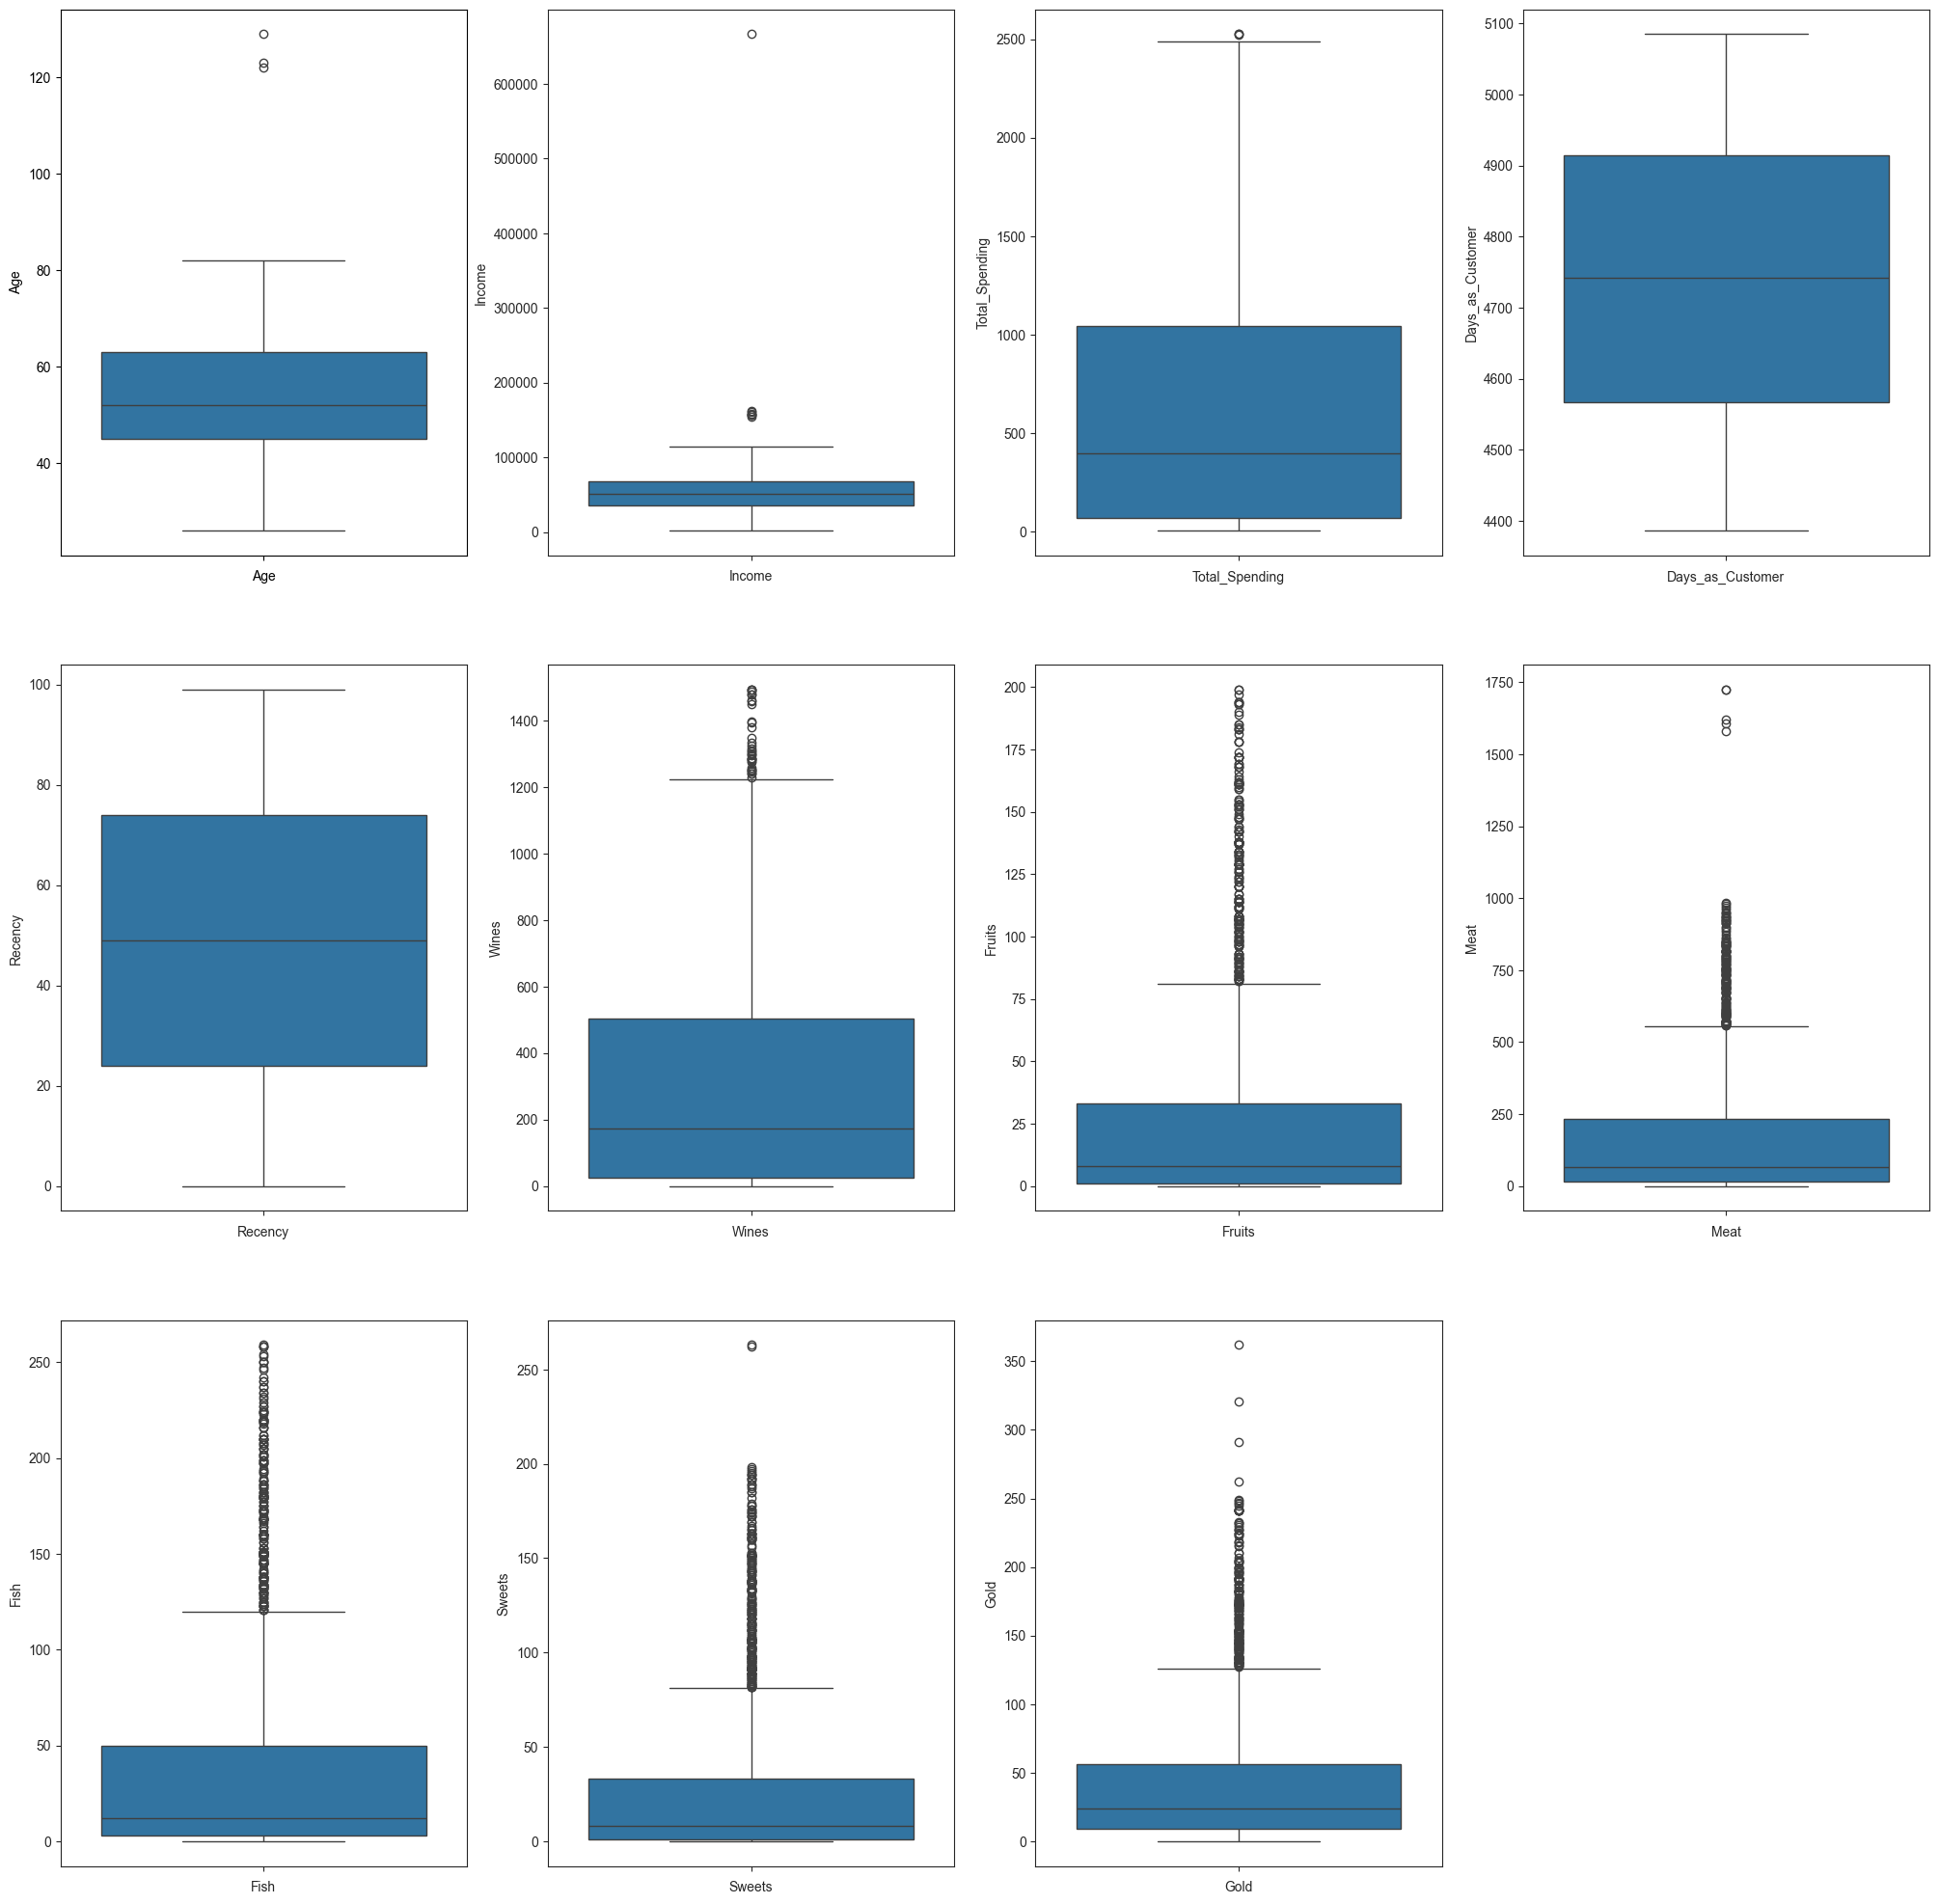

In [27]:
plt.figure(figsize=(25,25))
for i in range(0,len(conti_col)):
    plt.subplot(3,4,i+1)
    sns.set_style('ticks')
    sns.boxplot(data=df[conti_col[i]])
    plt.xlabel(conti_col[i])
# doubt - wh we only visvalize conti col why not both conti &descret 

In [28]:
def outlier(col):
    for column in col:
        percentile_25 = df[column].quantile(0.25)
        percentile_75 = df[column].quantile(0.75)
        iqr = percentile_75-percentile_25
        lower_limit = percentile_25-1.5*iqr
        upper_limit = percentile_75+1.5*iqr
        print(f'\n###{column}###\nhigher bound: {upper_limit}\nlow bound: {lower_limit}\n')
        df.loc[(df[column]>upper_limit), column]= upper_limit
        df.loc[(df[column]<lower_limit), column]= lower_limit    

In [29]:
outlier(conti_col)


###Age###
higher bound: 90.0
low bound: 18.0


###Income###
higher bound: 117416.25
low bound: -13587.75


###Total_Spending###
higher bound: 2510.625
low bound: -1396.375


###Days_as_Customer###
higher bound: 5437.375
low bound: 4044.375


###Recency###
higher bound: 149.0
low bound: -51.0


###Wines###
higher bound: 1225.0
low bound: -697.0


###Fruits###
higher bound: 81.0
low bound: -47.0


###Meat###
higher bound: 556.0
low bound: -308.0


###Fish###
higher bound: 120.5
low bound: -67.5


###Sweets###
higher bound: 81.0
low bound: -47.0


###Gold###
higher bound: 126.5
low bound: -61.5



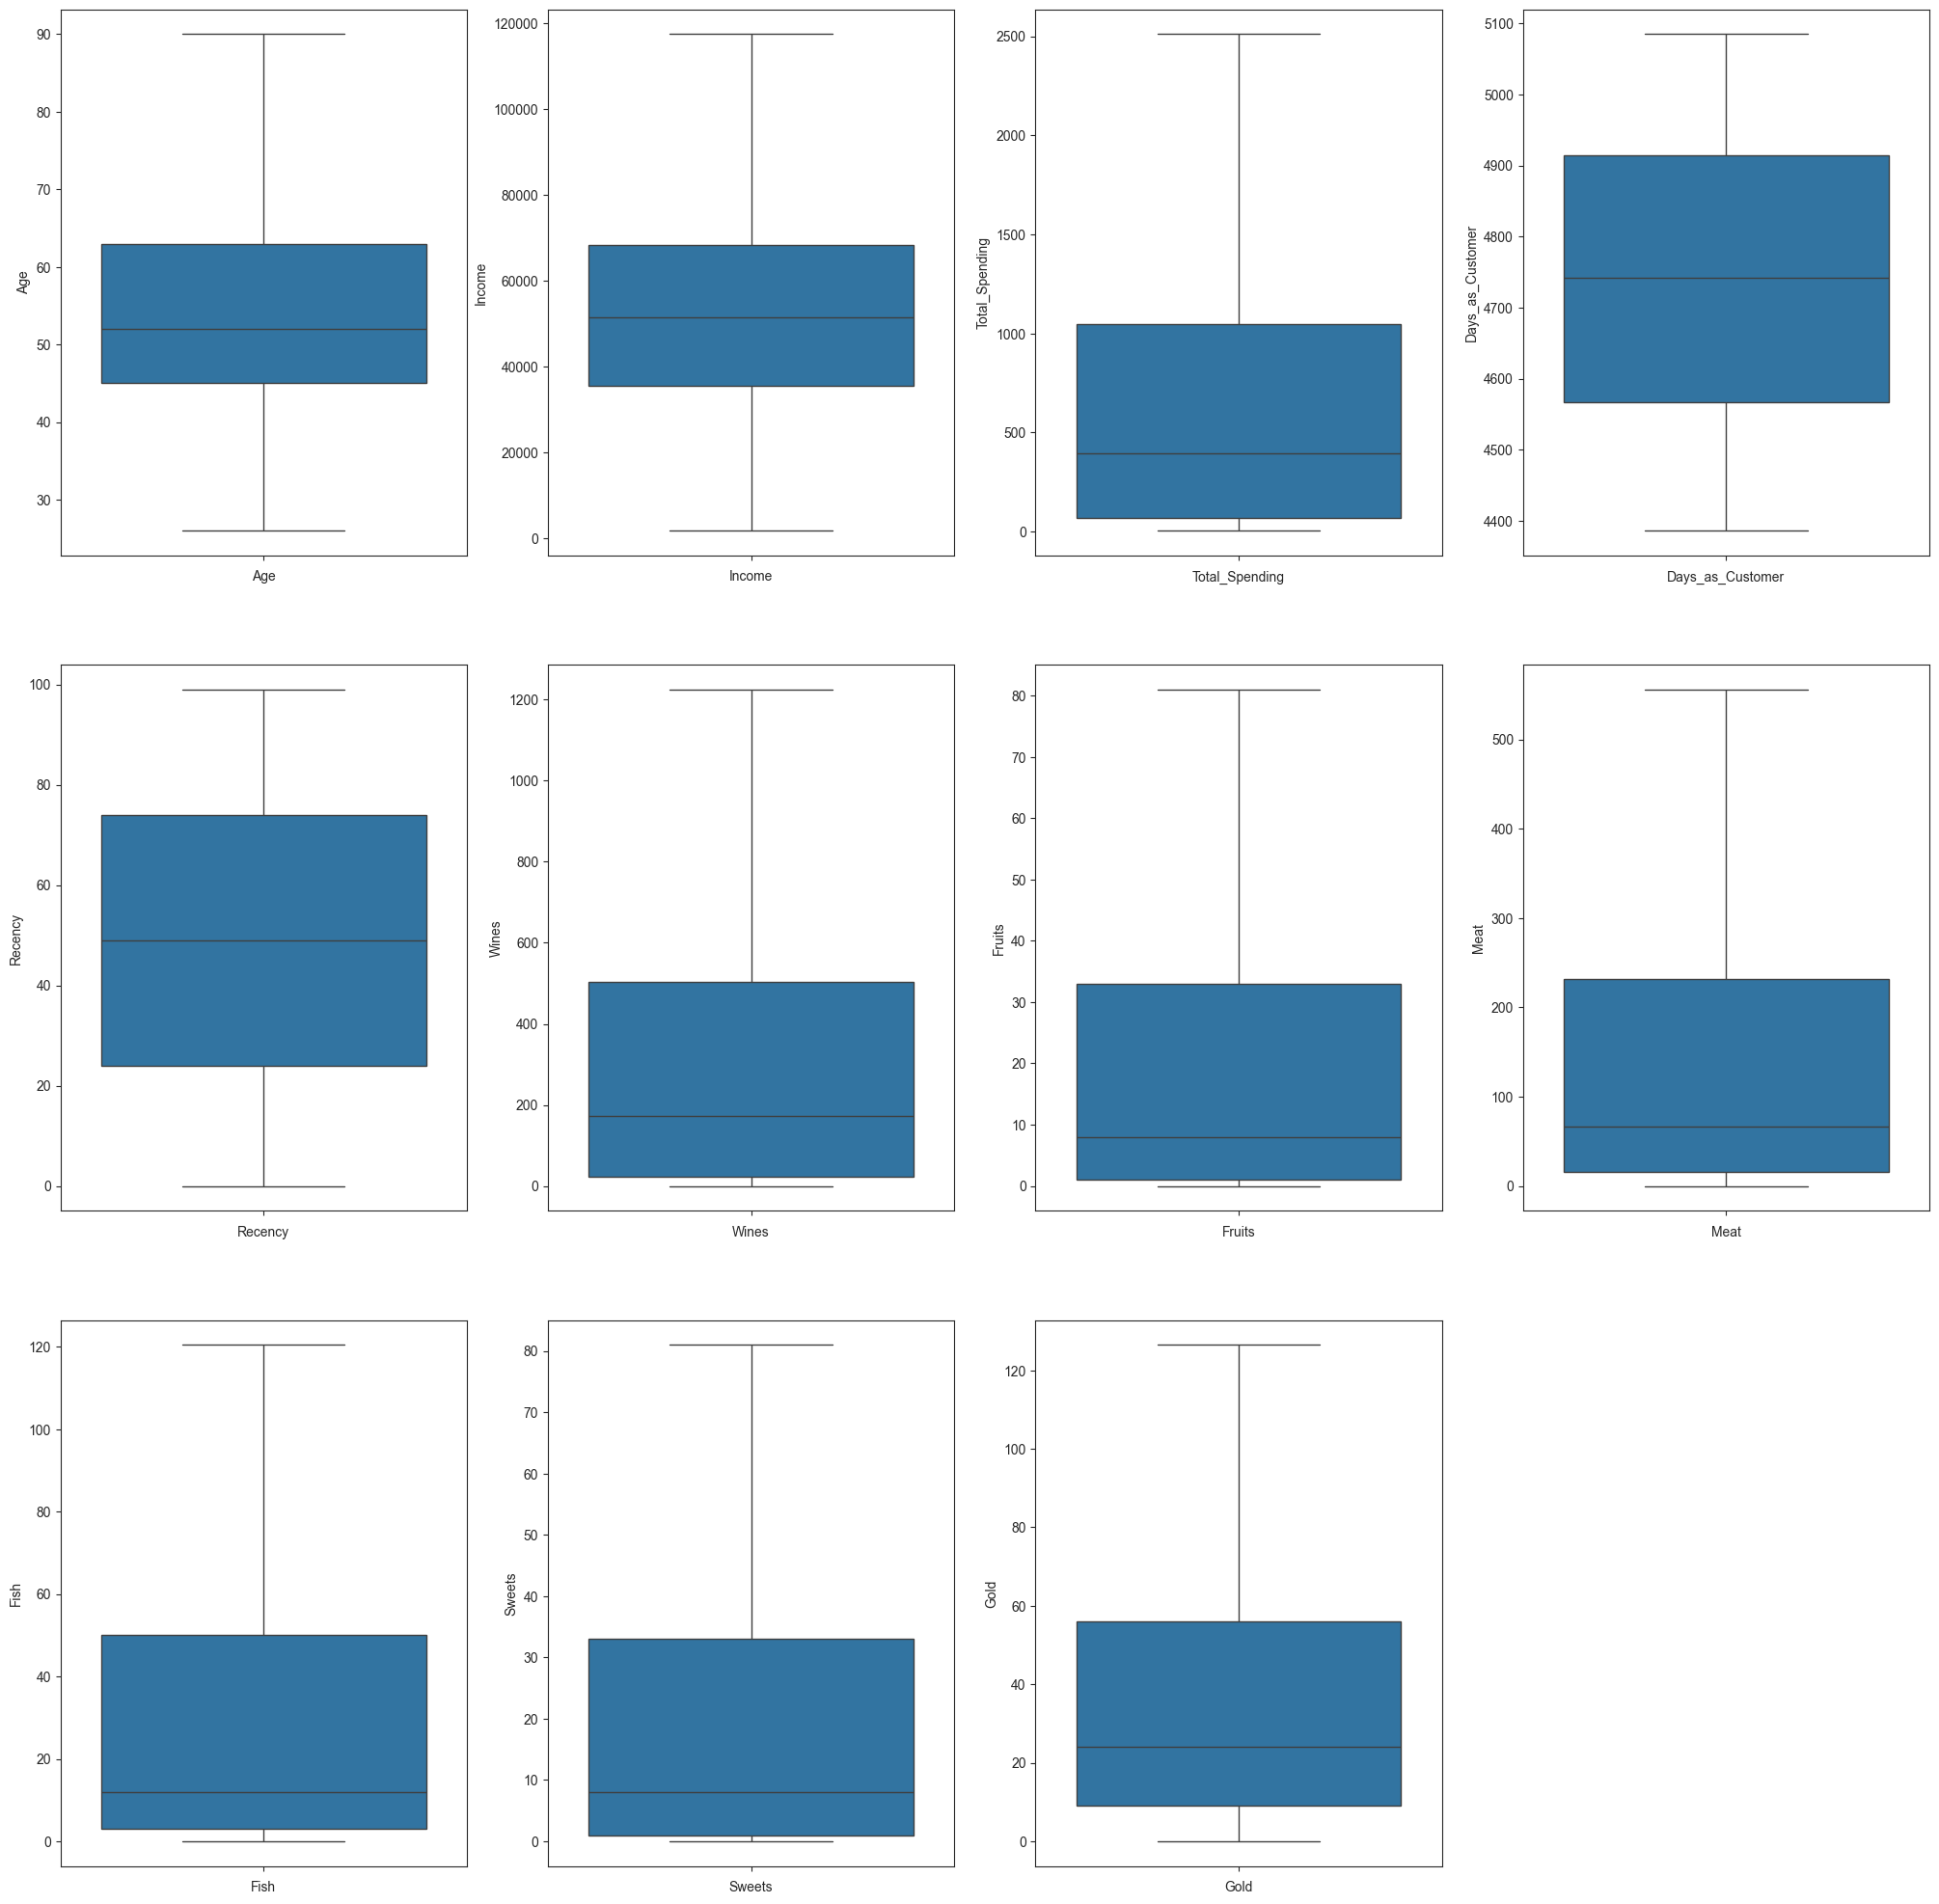

In [30]:
plt.figure(figsize=(25,25))
for i in range(0,len(conti_col)):
    plt.subplot(3,4,i+1)
    sns.set_style('ticks')
    sns.boxplot(data=df[conti_col[i]])
    plt.xlabel(conti_col[i])


In [31]:
df_copyy = df.copy()


In [32]:
numeric_feat = [num for num in df_copyy.columns if df_copyy[num].dtype != 'object']
outlier_feat = ['Wines','Fruits','Meat','Fish','Sweets','Gold','Age','Total_Spending']# doubt - we have fix the outlier the [roblem soo why a differnet list like this
numeric_feat = [num for num in numeric_feat  if num not in outlier_feat]

In [33]:
numeric_feature = Pipeline(steps=[('imputer',SimpleImputer(strategy='median')),('scaler',StandardScaler())])
outlier_feature = Pipeline(steps=[('imputer',SimpleImputer(strategy='median')),('scaler_p',PowerTransformer(standardize=True))])
preprocessing = ColumnTransformer([('num_col',numeric_feature,numeric_feat),('outlier_col',outlier_feature,outlier_feat)])

In [34]:
col=df_copyy.columns
df_copyy=preprocessing.fit_transform(df_copyy)
scaled_data = pd.DataFrame(df_copyy,columns=col)

In [35]:
scaled_data.head()

,Age,Education,Marital Status,Parental Status,Children,Income,Total_Spending,Days_as_Customer,Recency,Wines,...,Meat,Fish,Sweets,Gold,Web,Catalog,Store,Discount Purchases,Total Promo,NumWebVisitsMonth
0,-0.458383,-1.346874,-1.584605,-1.264505,0.299651,1.531185,0.307039,1.409304,2.510890,-0.550785,...,-0.439037,0.693904,1.062784,1.487681,1.504406,1.493989,1.474200,1.196801,1.005341,1.315365
1,-0.458383,-1.346874,0.631072,1.396361,-0.263808,-1.190545,-0.383664,-1.110409,-0.568720,-1.166125,...,-0.439037,-0.130463,-1.211545,-1.001121,-1.376502,-0.889143,-0.987648,-0.967034,1.239521,-1.441417
2,-0.458383,0.742460,-1.584605,-1.264505,0.943420,-0.205773,-0.798086,1.409304,-0.226541,1.295237,...,-0.439037,-0.542647,0.748918,1.145877,0.456428,1.435812,0.579704,0.473642,0.361223,0.661170
3,-0.458383,0.742460,0.631072,0.065928,-1.204881,-1.061881,-0.798086,-0.750450,-0.910898,-0.550785,...,-0.439037,0.281720,-1.211545,-0.403311,-0.722233,-0.110828,-0.542753,-1.069040,-1.315014,-1.117211
4,1.533425,0.742460,0.631072,0.065928,0.307056,-0.953012,1.550305,0.329427,0.115638,0.064556,...,-0.439037,-0.130463,0.123712,1.058075,0.406278,0.832291,0.741799,-0.368949,-1.033428,0.179322


In [36]:
def silhouette_plot(model,range_of_cluster ,X_clustering,pca,**kwargs):
    for i in range_of_cluster:
        fig , (ax1,ax2) = plt.subplot(1,2)
        fig.set_size_inches(10,7)
        clustering = model(n_cluster = i , **kwargs)
        model_predict = clustering.fit_predict(X_clustering,clustering)
        silhouettescore=silhouette_score(X_clustering,model_predict)
        fprint(f'for n_cluster {i} the score is {silhouettescore}')
        silhouettesamples=silhouette_samples(X_clustering,model_predict)
    start_y = 10

    for cluster in range(n_clusters):
        cluster_scores = sample_silhouette_values[cluster_labels == cluster]
        cluster_scores.sort()
        cluster_size = len(cluster_scores)
        end_y = start_y + cluster_size
        ax1.fill_betweenx(
        np.arange(start_y, end_y),
        0,
        cluster_scores,
        color=plt.cm.tab10(cluster),
        alpha=0.7
    )

        ax1.text(-0.05, start_y + cluster_size / 2, cluster)

        start_y = end_y + 10


    ax1.set_title("Silhouette Plot")
    ax1.set_xlabel("Silhouette Score")
    ax1.set_ylabel("Clusters")
    ax1.axvline(silhouette_avg, color="red", linestyle="--")
    ax1.set_yticks([])


    sns.scatterplot(
    x=pca[:, 0],
    y=pca[:, 1],
    hue=cluster_labels,
    palette="tab10",
    ax=ax2
    )

    ax2.set_title("Cluster Visualization")
    ax2.set_xlabel("PCA Component 1")
    ax2.set_ylabel("PCA Component 2")

    plt.suptitle(f"{model.__name__} (n_clusters = {n_clusters})")
    plt.show()